# Data

In [ ]:
from huggingface_hub import hf_hub_download, login

In [ ]:
login()

In [ ]:
hf_hub_download(repo_id='Jungle15/GDP-HMM_Challenge', filename='train_HaN.zip', repo_type="dataset", local_dir='.')

In [ ]:
hf_hub_download(repo_id='Jungle15/GDP-HMM_Challenge', filename='train_Lung.zip', repo_type="dataset", local_dir='.')

# Train

In [1]:
from pathlib import Path
import sys

code_dir = Path('/workspace/gdp-hmm-model')
sys.path.append(str(code_dir)) # Need to be string
sys.path.append(str(code_dir/'mednext'))

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from nnunet_mednext import create_mednext_v1
import yaml
from pprint import pprint

from tqdm import tqdm
import numpy as np

In [3]:
%load_ext autoreload
%autoreload 2

import data_loader



In [4]:
cfig = yaml.load(open(code_dir / 'config_files/config.yaml'), Loader=yaml.FullLoader)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# loaders = data_loader.GetLoader(cfig = cfig['loader_params'])
# train_loader =loaders.train_dataloader()
# val_loader = loaders.val_dataloader()

In [6]:
# model = create_mednext_v1( num_input_channels = cfig['model_params']['num_input_channels'],
#   num_classes = cfig['model_params']['out_channels'],
#   model_id = cfig['model_params']['model_id'],          # S, B, M and L are valid model ids
#   kernel_size = cfig['model_params']['kernel_size'],   # 3x3x3 and 5x5x5 were tested in publication
#   deep_supervision = cfig['model_params']['deep_supervision']
# ).to(device)

In [5]:
model = create_mednext_v1( num_input_channels = 7,
  num_classes = cfig['model_params']['out_channels'],
  model_id = cfig['model_params']['model_id'],          # S, B, M and L are valid model ids
  kernel_size = cfig['model_params']['kernel_size'],   # 3x3x3 and 5x5x5 were tested in publication
  deep_supervision = cfig['model_params']['deep_supervision']
).to(device)

In [6]:
model.load_state_dict(torch.load('weights/7c_v2.pt'))

<All keys matched successfully>

# Dataset and DataLoader

In [5]:
from pathlib import Path
import numpy as np
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [6]:
# Fixed length, random sampled
# extra param: size -> size of the dataset

class ChallengeData(Dataset):
    def __init__(self, data_dir, ids, size=None):
        super().__init__()
        self.data_dir = Path(data_dir)
        self.ids = ids
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.size = size if size is not None else len(ids)
        self._sample()

    def __len__(self):
        return self.size

    def _sample(self):
        if self.size < len(self.ids):
            self.current_ids = np.random.choice(self.ids, self.size, replace=False).tolist()
            print('Dataset resampled')
        else:
            self.current_ids = self.ids.copy()
            print('Dataset all samples used')

    def __getitem__(self, idx):
        npz_path = self.data_dir / f'{self.current_ids[idx]}.npz'

        data_dict = dict(np.load(npz_path))

        # Unsqueeze the 1st dim: x -> (8, 96, 128, 144)
        x = torch.from_numpy(data_dict['data'])[0].to(self.device)
        y = torch.from_numpy(data_dict['label'])[0].to(self.device)

        # Mask, derived from x
        body_mask = x[3:4,...].bool()
        outbody_mask = ~body_mask
        ptv_mask = x[1:2, ...].bool()
        near_mask = torch.logical_and(~ptv_mask, body_mask)

        if idx==self.size-1: self._sample()

        info = x[-1].mean((1, 2))[:4].cpu().tolist()
            
        return x[:-1], y, body_mask, outbody_mask, ptv_mask, near_mask, info

In [7]:
from sklearn.model_selection import train_test_split

others, test_ids = train_test_split(range(2728), test_size=0.3, random_state=1234)
train_ids, val_ids = train_test_split(others, test_size=0.3, random_state=1234)

In [8]:
batch_size = 4

data_tr = ChallengeData('/workspace/data/train_data_dict', train_ids, size=100)
loader_tr = DataLoader(data_tr, batch_size=batch_size, shuffle=False)

data_vl = ChallengeData('/workspace/data/train_data_dict', val_ids, size=20)
loader_vl = DataLoader(data_vl, batch_size=batch_size, shuffle=False)

data_ts = ChallengeData('/workspace/data/train_data_dict', test_ids)
loader_ts = DataLoader(data_ts, batch_size=1, shuffle=False)


Dataset resampled
Dataset resampled
Dataset all samples used


In [ ]:
len(data_tr), len(data_vl), len(data_ts)

In [ ]:
x, y, body_mask, outbody_mask, ptv_mask, near_mask, info = data_tr[0]

In [ ]:
x.shape, info

In [10]:
optimizer = optim.Adam(model.parameters(), lr=cfig['lr'])
criterion = nn.L1Loss()
epochs = 10

In [9]:
def cal_error(pred, gt, body):
    isodose_5Gy_mask = ((gt > 0.5) | (pred > 0.5)) & (body > 0)
    isodose_ref_5Gy_mask = (gt > 0.5) & (body > 0)
    diff = gt - pred
    error = torch.sum(torch.abs(diff)[isodose_5Gy_mask > 0]) / torch.sum(isodose_ref_5Gy_mask)
    return error

def custom_loss(outputs, y, body_mask, outbody_mask, ptv_mask, near_mask, _id):
    if _id == 1:
        loss = criterion(outputs, y)
    if _id == 2:
        loss = criterion(outputs[body_mask], y[body_mask])
    if _id == 3:
        loss = criterion(outputs[body_mask], y[body_mask]) + 5 * criterion(outputs[near_mask], y[near_mask])
    if _id == 4:
        loss = cal_error(outputs, y, body_mask) + criterion(outputs, y) + torch.max(outputs[outbody_mask])

    return loss

def iso_5_dice(pred, gt, body):
    iso_mask = ((gt > 0.5) | (pred > 0.5)) & (body > 0)
    iso_mask_gt = (gt > 0.5) & (body > 0)
    return 2*(iso_mask*iso_mask_gt).sum() / (iso_mask.sum() + iso_mask_gt.sum())
    

In [13]:
loss_id = 4

In [ ]:
5e-4

In [36]:
optimizer = optim.Adam(model.parameters(), lr=1e-6)
loss_id = 2
epochs = 10

In [37]:
model.train()

for epoch in range(epochs):
    # if epoch % 20 == 0: torch.save(model.state_dict(), f'temp/temp_e{epoch}.pt')
    
    pbar = tqdm(loader_tr, f'Epoch {epoch}')
    
    train_loss = []
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in pbar:
        
      # Forward pass
      outputs = model(x.to(device))

      if loss_id == 1:
        loss = criterion(outputs, y)
      if loss_id == 2:
        loss = criterion(outputs[ptv_mask], y[ptv_mask])
      if loss_id == 3:
        loss = 1 * criterion(outputs[body_mask], y[body_mask]) + \
               10 * criterion(outputs[near_mask], y[near_mask]) + \
               1 * cal_error(outputs, y, body_mask) 
               #\ 10 * iso_5_dice(outputs, y, body_mask) 
              # 10 * criterion(outputs[outbody_mask], y[outbody_mask])
               
    
      if loss_id == 4:
        loss = 5 * criterion(outputs[ptv_mask], y[ptv_mask]) + \
               2 * criterion(outputs[near_mask], y[near_mask]) + \
               10 * iso_5_dice(outputs, y, body_mask) 
    
      # Backward pass and optimization
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    
      train_loss.append(loss.detach().cpu().item())
      pbar.set_postfix_str(f'Loss: {loss.item():.3f}')
    
    val_loss = []
    model.eval()
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in loader_vl:
        with torch.no_grad():
            outputs = model(x.to(device))
            # loss = cal_error(outputs, y, body_mask)
            loss = criterion(outputs[ptv_mask], y[ptv_mask])
            val_loss.append(loss.detach().cpu().item())
    
    print(f'Train loss: {np.mean(train_loss):.3f} ({np.std(train_loss):.3f}) '+ \
          f'Val loss: {np.mean(val_loss):.3f} ({np.std(val_loss):.3f})')


Epoch 0:  96%|█████████▌| 24/25 [00:24<00:01,  1.02s/it, Loss: 0.241]

Dataset resampled


Epoch 0: 100%|██████████| 25/25 [00:25<00:00,  1.02s/it, Loss: 0.226]


Dataset resampled
Train loss: 0.253 (0.057) Val loss: 0.268 (0.067)


Epoch 1:  96%|█████████▌| 24/25 [00:23<00:00,  1.02it/s, Loss: 0.284]

...

Dataset resampled
Train loss: 0.242 (0.055) Val loss: 0.222 (0.021)


Epoch 9:  96%|█████████▌| 24/25 [00:23<00:00,  1.02it/s, Loss: 0.243]

Dataset resampled


Epoch 9: 100%|██████████| 25/25 [00:24<00:00,  1.01it/s, Loss: 0.257]


Dataset resampled
Train loss: 0.243 (0.045) Val loss: 0.255 (0.062)


IndexError: index 1 is out of bounds for dimension 0 with size 1

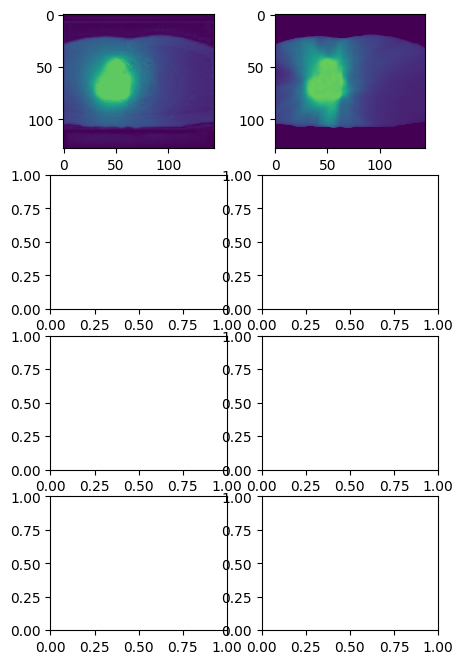

In [40]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(4, 2, figsize=(5, 8))
for i in range(4):
    ax[i,0].imshow(outputs[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,1].imshow(y.cpu()[i,0,50], vmin=0, vmax=8)
plt.tight_layout()

In [ ]:
ref_dose = y.cpu().numpy()
prediction = outputs.detach().cpu().numpy()
body = body_mask.cpu().numpy()

isodose_5Gy_mask = ((ref_dose > 5) | (prediction > 5)) & (body > 0) # the mask include the body AND the region where the dose/prediction is higher than 5Gy

isodose_ref_5Gy_mask = (ref_dose > 5) & (body > 0) # the mask include the body AND the region where the ref is higher than 5Gy

diff = ref_dose - prediction

error = np.sum(np.abs(diff)[isodose_5Gy_mask > 0]) / np.sum(isodose_ref_5Gy_mask)

In [ ]:
error

In [ ]:
cal_error(outputs.detach().cpu(), y.cpu(), body_mask.cpu().numpy())

In [ ]:
error

# Test

In [ ]:
ptv_mask.shape

In [36]:
x[:,0:1].max()

tensor(6.0000, device='cuda:0')

In [43]:
x[:, 0:1][ptv_mask].mean(), y[ptv_mask].mean(), outputs[ptv_mask].mean()

(tensor(5.4296, device='cuda:0'),
 tensor(6.0865, device='cuda:0'),
 tensor(6.1947, device='cuda:0'))

In [23]:
criterion(y[ptv_mask], outputs[ptv_mask])

tensor(0.3939, device='cuda:0')

In [50]:
cal_error(outputs, y, body_mask)

tensor(0.2533, device='cuda:0')

In [51]:
# def cal_error(pred, gt, body):

pred = outputs
gt = y
body = body_mask 

isodose_5Gy_mask = ((gt > 0.5) | (pred > 0.5)) & (body > 0)
isodose_ref_5Gy_mask = (gt > 0.5) & (body > 0)
diff = gt - pred
error = torch.sum(torch.abs(diff)[isodose_5Gy_mask > 0]) / torch.sum(isodose_ref_5Gy_mask)


In [67]:
isodose_5Gy_mask.sum(), body.sum(), isodose_ref_5Gy_mask.sum()

(tensor(429513, device='cuda:0'),
 tensor(976785, device='cuda:0'),
 tensor(410806, device='cuda:0'))

In [64]:
diff.squeeze().sum((1,2))

tensor([     0,      0,      0,      0,      0,      0,      0, -12875, -12998,
        -12998, -13118, -13223, -13277, -13347, -13347, -13371, -13412, -13412,
        -13496, -13496, -13460, -13409, -13409, -13374, -13346, -13311, -13088,
        -12625, -11947, -11430, -10483,  -8798,  -6280,  -4458,  -3658,  -2503,
          -958,   -331,   -147,    -51,    -90,    -73,    -67,    -49,    -23,
           -41,    -36,    -19,    -36,    -20,    -52,    -42,    -29,    -54,
           -43,    -86,   -120,   -158,   -338,   -415,   -810,   -925,  -1163,
         -1535,  -2066,  -2507,  -3594,  -4002,  -4777,  -5432,  -6518,  -7458,
         -8554,  -9169,  -9464,  -9625,  -9789,  -9696,  -9598,  -9505,  -9404,
         -9405,  -9307,  -9184,  -9022,  -8863,  -8863,  -8702,  -8554,  -8554,
             0,      0,      0,      0,      0,      0], device='cuda:0')

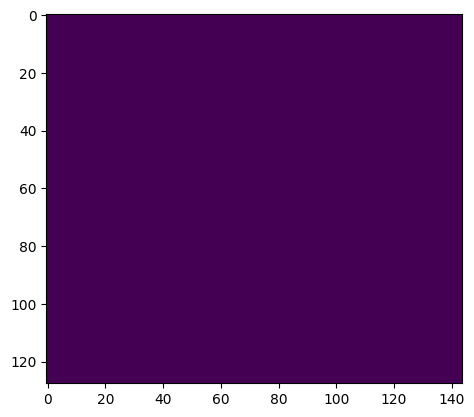

In [66]:
diff = isodose_5Gy_mask.int() - body.int()
plt.imshow(isodose_5Gy_mask[0,0,8].cpu())
# plt.imshow(body[0,0,8].cpu(), alpha=0.3)

In [38]:
ts_loss = []
model.eval()

pbar = tqdm(loader_ts)
for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in pbar:
    with torch.no_grad():
        outputs = model(x.to(device))
        # loss = criterion(outputs, y)
        
        # ptv_limit = outputs.clone()
        # ptv_limit[ptv_mask] = x[:,0:1,...][ptv_mask]
        # outputs = torch.min(outputs, ptv_limit)
        

        outputs = outputs.clip(0, x[:,0:1].max())
        loss = criterion(outputs[ptv_mask], y[ptv_mask])
        # loss = cal_error(outputs, y, body_mask)
        ts_loss.append(loss.detach().cpu().item())
        pbar.set_postfix_str(f'Test loss: {np.mean(ts_loss):.3f}')



100%|██████████| 819/819 [02:09<00:00,  6.32it/s, Test loss: 0.228]

Dataset all samples used


In [49]:
np.min(ts_loss)

0.18055470287799835

In [ ]:
## 7c v1 - 
# torch.save(model.state_dict(), 'weights/7c_v1.pt') # Test loss: 0.385
# torch.save(model.state_dict(), 'weights/7c_v2.pt') # Test loss: 0.348

In [39]:
# torch.save(model.state_dict(), 'weights/7c_ptv_v1.pt') # Test loss: 0.234
torch.save(model.state_dict(), 'weights/7c_ptv_v2.pt') # Test loss: 0.228


In [ ]:
torch.save(model.state_dict(), 'weights/candidate_1.pt')

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(outputs[0,0,50].detach().cpu(), vmin=0, vmax=8)
ax[1].imshow(x.cpu()[0,0,50], vmin=0, vmax=8)

In [ ]:
model.load_state_dict(torch.load('weights/candidate_1.pt'))

In [ ]:
torch.save(model.state_dict(), 'weights/candidate_2.pt')

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3, 2, figsize=(5, 8))
for i in range(3):
    ax[i,0].imshow(outputs[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,1].imshow(y.cpu()[i,0,50], vmin=0, vmax=8)
plt.tight_layout()

In [ ]:
model.load_state_dict(torch.load('weights/candidate_2_ft_v2.pt'))

In [ ]:
model.eval()
model.out_0.train()
model.dec_block_0.train()

model.up_0.train()


In [ ]:
model.stem.training, model.out_0.training, model.dec_block_0.training, model.up_0.training

In [ ]:
def img_grad(img):
    return img[..., :-1, :-1, :-1] - img[..., 1:, 1:, 1:]

def cal_grad_loss(pred, y, mask):
    _mask = mask[..., :-1, :-1, :-1]
    return criterion(img_grad(pred)[_mask], img_grad(y)[_mask])

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-6)
loss_id = 5

In [ ]:
for epoch in range(1):
    
    pbar = tqdm(loader_tr, f'Epoch {epoch}')
    
    train_loss = []
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask in pbar:
        
      # Forward pass
      outputs = model(x.to(device))

      if loss_id == 1:
        loss = criterion(outputs, y)
      if loss_id == 2:
        loss = criterion(outputs[body_mask], y[body_mask])
      if loss_id == 3:
        loss = 1 * criterion(outputs[body_mask], y[body_mask]) + \
               10 * criterion(outputs[near_mask], y[near_mask]) + \
               cal_error(outputs, y, body_mask) 
               # 30*iso_5_dice(outputs, y, body_mask) + \
              # 10 * criterion(outputs[outbody_mask], y[outbody_mask])
               
    
      if loss_id == 4:
        loss = cal_error(outputs, y, body_mask) + criterion(outputs, y) + torch.max(outputs[outbody_mask])

      if loss_id == 5:
        loss = 1 * cal_error(outputs, y, body_mask)  + \
               50 * cal_grad_loss(outputs, y, body_mask)
    
      # Backward pass and optimization
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    
      train_loss.append(loss.detach().cpu().item())
      pbar.set_postfix_str(f'Loss: {loss.item():.3f}')
    
    val_loss = []
    model.eval()
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask in loader_vl:
        with torch.no_grad():
            outputs = model(x.to(device))
            loss = cal_error(outputs, y, body_mask)
            val_loss.append(loss.detach().cpu().item())
    
    print(f'Train loss: {np.mean(train_loss):.3f} ({np.std(train_loss):.3f}) '+ \
          f'Val loss: {np.mean(val_loss):.3f} ({np.std(val_loss):.3f})')


In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(4, 2, figsize=(5, 8))
for i in range(4):
    ax[i,0].imshow(outputs[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,1].imshow(y.cpu()[i,0,50], vmin=0, vmax=8)
plt.tight_layout()

In [ ]:
ts_loss = []
model.eval()

pbar = tqdm(loader_ts)
for x, y, body_mask, outbody_mask, ptv_mask, near_mask in pbar:
    with torch.no_grad():
        outputs = model(x.to(device))
        # loss = criterion(outputs, y)
        
        loss = cal_error(outputs, y, body_mask)
        ts_loss.append(loss.detach().cpu().item())
        pbar.set_postfix_str(f'Test loss: {np.mean(ts_loss):.3f}')



In [ ]:
# temp = model.state_dict() # Test loss: 0.424
# temp2 = model.state_dict() # Test loss: 0.425

In [ ]:
model.load_state_dict(temp)

In [ ]:
# torch.save(temp, 'weights/candidate_2_ft_v3.1.pt')
# torch.save(temp2, 'weights/candidate_2_ft_v3.2.pt')

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3, 2, figsize=(5, 8))
for i in range(3):
    ax[i,0].imshow(outputs[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,1].imshow(y.cpu()[i,0,50], vmin=0, vmax=8)
plt.tight_layout()

# Near mask

In [47]:
model = create_mednext_v1(
      num_input_channels = 7,
      num_classes = 1,
      model_id = 'L',
      kernel_size = 3,
      deep_supervision = False
    ).to(device)

In [15]:
import os
os.chdir('mednext')

In [12]:
model.load_state_dict(torch.load('weights/7c_v2.pt'))


<All keys matched successfully>

In [52]:
optimizer = optim.Adam(model.parameters(), lr=1e-6)
criterion = nn.L1Loss()
epochs = 10
loss_id = 3

In [ ]:
model.train()

for epoch in range(epochs):
    # if epoch % 20 == 0: torch.save(model.state_dict(), f'temp/temp_e{epoch}.pt')
    
    pbar = tqdm(loader_tr, f'Epoch {epoch}')
    train_loss = []
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in pbar:
        
      # Forward pass
      outputs = model(x.to(device))

      if loss_id == 1:
        loss = cal_error(outputs, y, body_mask)
      if loss_id == 2:
        loss = criterion(outputs[near_mask], y[near_mask])
      if loss_id == 3:
        mask = (y > 0.5) & near_mask
        loss = criterion(outputs[mask], y[mask])

    
      # Backward pass and optimization
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    
      train_loss.append(loss.detach().cpu().item())
      pbar.set_postfix_str(f'Loss: {loss.item():.3f}')

    
    val_loss = []
    model.eval()
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in loader_vl:
        with torch.no_grad():
            outputs = model(x.to(device))
            mask = (y > 0.5) & near_mask
            loss = criterion(outputs[mask], y[mask])
            
            val_loss.append(loss.detach().cpu().item())
    
    print(f'Train loss: {np.mean(train_loss):.3f} ({np.std(train_loss):.3f}) '+ \
          f'Val loss: {np.mean(val_loss):.3f} ({np.std(val_loss):.3f})')


Epoch 0:  96%|█████████▌| 24/25 [00:45<00:01,  1.88s/it, Loss: 0.705]

Dataset resampled


Epoch 0: 100%|██████████| 25/25 [00:47<00:00,  1.89s/it, Loss: 0.503]


Dataset resampled
Train loss: 0.524 (0.061) Val loss: 0.544 (0.109)


Epoch 1:  96%|█████████▌| 24/25 [00:45<00:01,  1.88s/it, Loss: 0.485]

...

Epoch 2:  96%|█████████▌| 24/25 [00:45<00:01,  1.88s/it, Loss: 0.477]

Dataset resampled


Epoch 2: 100%|██████████| 25/25 [00:47<00:00,  1.88s/it, Loss: 0.514]


Dataset resampled
Train loss: 0.521 (0.059) Val loss: 0.520 (0.062)


Epoch 3:  68%|██████▊   | 17/25 [00:31<00:14,  1.87s/it, Loss: 0.441]

In [37]:
ts_loss = []
model.eval()

pbar = tqdm(loader_ts)
for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in pbar:
    with torch.no_grad():
        outputs = model(x.to(device))
        mask = (y > 0.5) & near_mask
        loss = criterion(outputs[mask], y[mask])
        # loss = criterion(outputs, y)
        
        # ptv_limit = outputs.clone()
        # ptv_limit[ptv_mask] = x[:,0:1,...][ptv_mask]
        # outputs = torch.min(outputs, ptv_limit)
        

        outputs = outputs.clip(0, x[:,0:1].max())
        loss = criterion(outputs[near_mask], y[near_mask])

        ts_loss.append(loss.detach().cpu().item())
        pbar.set_postfix_str(f'Test loss: {np.mean(ts_loss):.3f}')



100%|██████████| 819/819 [02:04<00:00,  6.57it/s, Test loss: 0.336]

Dataset all samples used


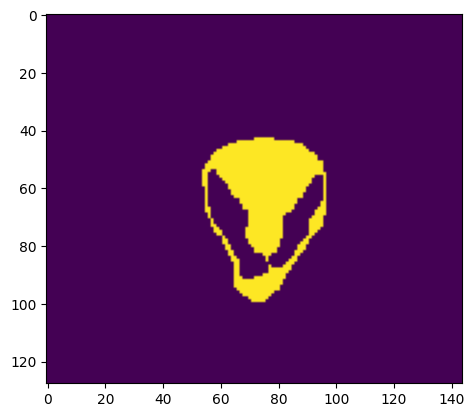

In [18]:
plt.imshow(mask[0,0,50].cpu())

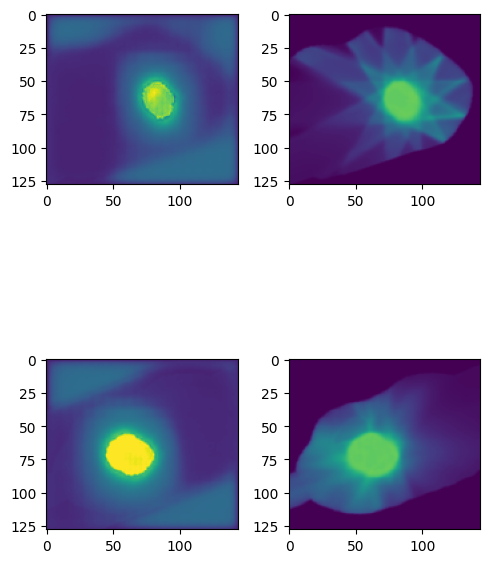

In [46]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 2, figsize=(5, 8))
for i in range(2):
    ax[i,0].imshow(outputs[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,1].imshow(y.cpu()[i,0,50], vmin=0, vmax=8)
plt.tight_layout()

In [76]:
# torch.save(model.state_dict(), 'weights/7c_near_v2.pt') # Test loss: 0.228
torch.save(model.state_dict(), 'weights/7c_near_v3.pt') # Test loss: 0.201

In [65]:
l = DataLoader(ChallengeData('/workspace/data/train_data_dict', train_ids), batch_size=batch_size, shuffle=False)

near_dose_max = []
for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in tqdm(l):
    near_dose = y[near_mask]
    near_dose_max.append(near_dose.max().item())

Dataset all samples used


100%|██████████| 334/334 [01:45<00:00,  3.16it/s]

Dataset all samples used


In [77]:
np.max(near_dose_max)

7.779531955718994

# Isodose model

In [31]:
model.load_state_dict(torch.load('weights/7c_v2.pt'))


<All keys matched successfully>

In [26]:
from torch.nn.functional import sigmoid

In [27]:
sigmoid(torch.tensor((-100, 0, 100)))

tensor([0.0000, 0.5000, 1.0000])

In [32]:
def dice(pred, gt):
    return -2*(pred*gt).sum() / (pred.sum() + gt.sum())

In [50]:
optimizer = optim.Adam(model.parameters(), lr=1e-6)
epochs = 10
loss_id = 3

In [52]:
model.train()

for epoch in range(epochs):
    # if epoch % 20 == 0: torch.save(model.state_dict(), f'temp/temp_e{epoch}.pt')
    
    pbar = tqdm(loader_tr, f'Epoch {epoch}')
    
    train_loss = []
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in pbar:
        
      # Forward pass
      outputs = model(x.to(device))
      outputs = sigmoid(outputs)
      y = (y>0.5).float()

      if loss_id == 1:
        loss = criterion(outputs, y)
      if loss_id == 2:
        loss = criterion(outputs[near_mask], y[near_mask])

      if loss_id == 3:
        loss = dice(outputs, y)
    
      # Backward pass and optimization
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    
      train_loss.append(loss.detach().cpu().item())
      pbar.set_postfix_str(f'Loss: {loss.item():.3f}')
    
    val_loss = []
    model.eval()
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in loader_vl:
        with torch.no_grad():
            outputs = model(x.to(device))
            outputs = sigmoid(outputs)
            y = (y>0.5).float()
            loss = dice(outputs, y)
            val_loss.append(loss.detach().cpu().item())
    
    print(f'Train loss: {np.mean(train_loss):.3f} ({np.std(train_loss):.3f}) '+ \
          f'Val loss: {np.mean(val_loss):.3f} ({np.std(val_loss):.3f})')


Epoch 0:  96%|█████████▌| 24/25 [00:23<00:00,  1.01it/s, Loss: -0.928]

Dataset resampled


Epoch 0: 100%|██████████| 25/25 [00:24<00:00,  1.01it/s, Loss: -0.948]


Dataset resampled
Train loss: -0.948 (0.012) Val loss: -0.940 (0.019)


Epoch 1:  96%|█████████▌| 24/25 [00:23<00:00,  1.02it/s, Loss: -0.958]

...

Dataset resampled
Train loss: -0.942 (0.017) Val loss: -0.935 (0.024)


Epoch 9:  96%|█████████▌| 24/25 [00:23<00:00,  1.01it/s, Loss: -0.944]

Dataset resampled


Epoch 9: 100%|██████████| 25/25 [00:24<00:00,  1.02it/s, Loss: -0.954]


Dataset resampled
Train loss: -0.946 (0.016) Val loss: -0.943 (0.009)


IndexError: index 1 is out of bounds for dimension 0 with size 1

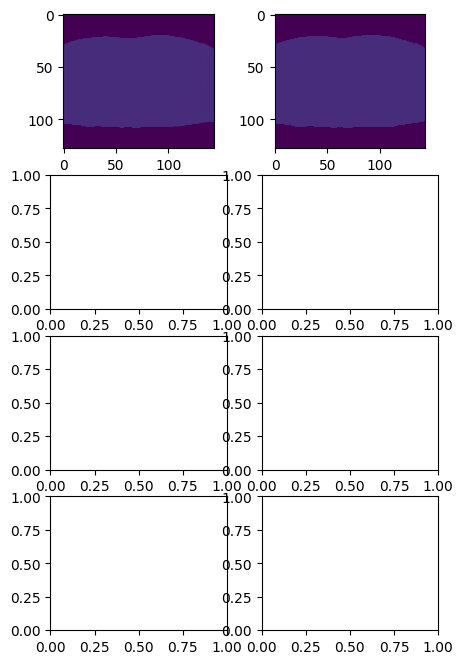

In [54]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(4, 2, figsize=(5, 8))
for i in range(4):
    ax[i,0].imshow(outputs[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,1].imshow(y.cpu()[i,0,50], vmin=0, vmax=8)
plt.tight_layout()

In [53]:
ts_loss = []
model.eval()

pbar = tqdm(loader_ts)
for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in pbar:
    with torch.no_grad():
        outputs = model(x.to(device))
        outputs = sigmoid(outputs)
        y = (y>0.5).float()
        loss = dice(outputs, y)

        ts_loss.append(loss.detach().cpu().item())
        pbar.set_postfix_str(f'Test loss: {np.mean(ts_loss):.3f}')



100%|██████████| 819/819 [02:03<00:00,  6.63it/s, Test loss: -0.942]

Dataset all samples used


In [49]:
torch.save(model.state_dict(), 'weights/7c_iso_v1.pt') # Test loss: -0.942


# Test whole

In [68]:
from torch.nn.functional import sigmoid

def load_model(weight_path):
    model = create_mednext_v1(
      num_input_channels = 7,
      num_classes = 1,
      model_id = 'B',
      kernel_size = 3,
      deep_supervision = False
    ).to(device)
    model.load_state_dict(torch.load(weight_path))
    return model

p_model = load_model('weights/7c_ptv_v2.pt')
n_model = load_model('weights/7c_near_v3.pt')
iso_model = load_model('weights/7c_iso_v1.pt')


ts_loss = []
model.eval()

pbar = tqdm(loader_ts)
for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in pbar:
    with torch.no_grad():
        
        outputs = p_model(x)
        n_outputs = n_model(x)
        outputs[near_mask] = n_outputs[near_mask]
        iso = sigmoid(iso_model(x))
        outputs[iso<0.5] = 0

        outputs = outputs.clip(0, x[:,0:1].max())
        loss = cal_error(outputs, y, body_mask)

        # l1 = criterion(outputs[ptv_mask], y[ptv_mask])
        # l2 = criterion(outputs[near_mask], y[near_mask])
        # pbar.set_postfix_str(f'Test loss: {l1.item()} {l2.item()}')

        ts_loss.append(loss.detach().cpu().item())
        pbar.set_postfix_str(f'Test loss: {np.mean(ts_loss):.3f}')




  4%|▍         | 32/819 [00:09<03:46,  3.47it/s, Test loss: 0.368]


KeyboardInterrupt: 

In [56]:
dice(outputs>0.5, y>0.5)

tensor(-0.9507, device='cuda:0')

In [69]:
pred = outputs
gt = y
body = body_mask 
isodose_5Gy_mask = ((gt > 0.5) | (pred > 0.5)) & (body > 0)
isodose_ref_5Gy_mask = (gt > 0.5) & (body > 0)
diff = gt - pred
error = torch.sum(torch.abs(diff)[isodose_5Gy_mask > 0]) / torch.sum(isodose_ref_5Gy_mask)

In [70]:
dice(isodose_5Gy_mask, isodose_ref_5Gy_mask)

tensor(-0.9951, device='cuda:0')

In [71]:
diff = gt - pred

In [74]:
torch.sum(torch.abs(diff)[isodose_5Gy_mask > 0]) / torch.sum(isodose_5Gy_mask)

tensor(0.3228, device='cuda:0')

In [90]:
(outputs[isodose_5Gy_mask]-y[isodose_5Gy_mask]).abs().mean()

tensor(0.3228, device='cuda:0')

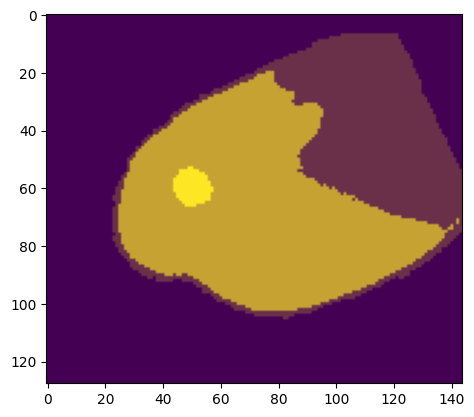

In [91]:
plt.imshow(isodose_5Gy_mask.cpu()[0,0,40])
plt.imshow(body_mask.cpu()[0,0,40], alpha=0.3)
plt.imshow(ptv_mask.cpu()[0,0,40], alpha=0.3)

In [73]:
ts_loss

[0.3124440610408783,
 0.7400901317596436,
 0.32319432497024536,
 0.4148455262184143,
 0.30909425020217896,
 0.3876291811466217,
 0.3590698540210724,
 0.42597436904907227,
 0.32487308979034424,
 0.3748989999294281,
 0.401323139667511,
 0.3366522490978241,
 0.3718299865722656,
 0.3435279428958893,
 0.27403873205184937,
 0.3404203951358795,
 0.4427838623523712,
 0.30645355582237244,
 0.31338122487068176,
 0.42024004459381104,
 0.5142767429351807,
 0.47907984256744385,
 0.24898259341716766,
 0.3316274881362915,
 0.25812792778015137,
 0.3103984594345093,
 0.35298970341682434,
 0.37207725644111633,
 0.3745422959327698,
 0.3367532789707184,
 0.35602518916130066,
 0.32596760988235474]